<a href="https://colab.research.google.com/github/mozza-ananda/bigquery-learning/blob/main/Ekspor_Kopi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Memanggil package
library(readr)
library(dplyr)
library(ggplot2)
library(lubridate)

library(forecast)  # auto.arima, Arima, forecast, accuracy
library(tseries)   # adf.test, kpss.test
library(lmtest)    # coeftest (uji signifikansi parameter)
library(zoo)       # kalau tadi imputasi pakai na.approx / na.spline

In [ ]:
# Membaca file CSV
data_2020 <- read_csv("2020_Ekspor_Kopi_Indonesia_Dunia.csv")
data_2021 <- read_csv("2021_Ekspor_Kopi_Indonesia_Dunia.csv")
data_2022 <- read_csv("2022_Ekspor_Kopi_Indonesia_Dunia.csv")
data_2023 <- read_csv("2023_Ekspor_Kopi_Indonesia_Dunia.csv")
data_2024 <- read_csv("2024_Ekspor_Kopi_Indonesia_Dunia.csv")
data_2025 <- read_csv("2025_Ekspor_Kopi_Indonesia_Dunia.csv")

# Melihat 6 baris pertama
head(data_2020)

names(data_2020)

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 12 Columns: 47
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (20): typeCode, freqCode, reporterISO, reporterDesc, flowCode, flowDesc,...
dbl (20): refPeriodId, refYear, refMonth, period, reporterCode, partnerCode,...
lgl  (7): isOriginalClassification, isLeaf, isQtyEstimated, isAltQtyEstimate...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 12 Columns: 47
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (20): typeCode, freqCode, reporterISO, reporterDesc, flowCode, flowDesc,...
dbl (19): ref

typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,⋯,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<dbl>,<lgl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>
C,M,20200101,2020,1,202001,360,IDN,Indonesia,X,⋯,28812482,FALSE,0,FALSE,0,71945333,71945333,0,FALSE,"true,"
C,M,20200201,2020,2,202002,360,IDN,Indonesia,X,⋯,27176520,FALSE,0,FALSE,0,64808946,64808946,0,FALSE,"true,"
C,M,20200301,2020,3,202003,360,IDN,Indonesia,X,⋯,26284078,FALSE,0,FALSE,0,66257411,66257411,0,FALSE,"true,"
C,M,20200401,2020,4,202004,360,IDN,Indonesia,X,⋯,26696187,FALSE,0,FALSE,0,63528175,63528175,0,FALSE,"true,"
C,M,20200501,2020,5,202005,360,IDN,Indonesia,X,⋯,18034712,FALSE,0,FALSE,0,45399620,45399620,0,FALSE,"true,"
C,M,20200601,2020,6,202006,360,IDN,Indonesia,X,⋯,28577178,FALSE,0,FALSE,0,60926353,60926353,0,FALSE,"true,"


[1] "typeCode"                 "freqCode"                
 [3] "refPeriodId"              "refYear"                 
 [5] "refMonth"                 "period"                  
 [7] "reporterCode"             "reporterISO"             
 [9] "reporterDesc"             "flowCode"                
[11] "flowDesc"                 "partnerCode"             
[13] "partnerISO"               "partnerDesc"             
[15] "partner2Code"             "partner2ISO"             
[17] "partner2Desc"             "classificationCode"      
[19] "classificationSearchCode" "isOriginalClassification"
[21] "cmdCode"                  "cmdDesc"                 
[23] "aggrLevel"                "isLeaf"                  
[25] "customsCode"              "customsDesc"             
[27] "mosCode"                  "motCode"                 
[29] "motDesc"                  "qtyUnitCode"             
[31] "qtyUnitAbbr"              "qty"                     
[33] "isQtyEstimated"           "altQtyUnitCode"          
[35] "altQtyUnitAbbr"           "altQty"                  
[37] "isAltQtyEstimated"        "netWgt"                  
[39] "isNetWgtEstimated"        "grossWgt"                
[41] "isGrossWgtEstimated"      "cifvalue"                
[43] "fobvalue"                 "primaryValue"            
[45] "legacyEstimationFlag"     "isReported"              
[47] "isAggregate"

In [ ]:
names(data_2020)[grep(
  "qty|quantity|weight|wgt",
  names(data_2020),
  ignore.case = TRUE
)]

[1] "qtyUnitCode"         "qtyUnitAbbr"         "qty"                
 [4] "isQtyEstimated"      "altQtyUnitCode"      "altQtyUnitAbbr"     
 [7] "altQty"              "isAltQtyEstimated"   "netWgt"             
[10] "isNetWgtEstimated"   "grossWgt"            "isGrossWgtEstimated"

In [ ]:
names(data_2025)[grep(
  "qty|quantity|weight|wgt",
  names(data_2025),
  ignore.case = TRUE
)]

[1] "qtyUnitCode"         "qtyUnitAbbr"         "qty"                
 [4] "isQtyEstimated"      "altQtyUnitCode"      "altQtyUnitAbbr"     
 [7] "altQty"              "isAltQtyEstimated"   "netWgt"             
[10] "isNetWgtEstimated"   "grossWgt"            "isGrossWgtEstimated"

In [ ]:
nrow(data_2020)
nrow(data_2021)
nrow(data_2022)
nrow(data_2023)
nrow(data_2024)
nrow(data_2025)

[1] 12

[1] 12

[1] 12

[1] 12

[1] 12

[1] 12

In [ ]:
str(data_2020)

str(data_2025)

spc_tbl_ [12 × 47] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ typeCode                : chr [1:12] "C" "C" "C" "C" ...
 $ freqCode                : chr [1:12] "M" "M" "M" "M" ...
 $ refPeriodId             : num [1:12] 20200101 20200201 20200301 20200401 20200501 ...
 $ refYear                 : num [1:12] 2020 2020 2020 2020 2020 2020 2020 2020 2020 2020 ...
 $ refMonth                : num [1:12] 1 2 3 4 5 6 7 8 9 10 ...
 $ period                  : num [1:12] 202001 202002 202003 202004 202005 ...
 $ reporterCode            : num [1:12] 360 360 360 360 360 360 360 360 360 360 ...
 $ reporterISO             : chr [1:12] "IDN" "IDN" "IDN" "IDN" ...
 $ reporterDesc            : chr [1:12] "Indonesia" "Indonesia" "Indonesia" "Indonesia" ...
 $ flowCode                : chr [1:12] "X" "X" "X" "X" ...
 $ flowDesc                : chr [1:12] "Export" "Export" "Export" "Export" ...
 $ partnerCode             : num [1:12] 0 0 0 0 0 0 0 0 0 0 ...
 $ partnerISO              : chr [1:12] "W00" 

In [ ]:
# Menggabungkan data tahun 2020-2025
data_kopi <- bind_rows(
  data_2020,
  data_2021,
  data_2022,
  data_2023,
  data_2024,
  data_2025
)

dim(data_kopi)

[1] 72 47

In [ ]:
table(data_kopi$refYear)

data_kopi %>%
  count(refYear, refMonth)


2020 2021 2022 2023 2024 2025 
  12   12   12   12   12   12 

refYear,refMonth,n
<dbl>,<dbl>,<int>
2020,1,1
2020,2,1
2020,3,1
2020,4,1
2020,5,1
2020,6,1
2020,7,1
2020,8,1
2020,9,1


In [ ]:
data_kopi <- data_kopi %>%
  mutate(
    tanggal = make_date(refYear, refMonth, 1)
  )

  data_kopi <- data_kopi %>%
  arrange(tanggal)

In [ ]:
data_kopi <- data_kopi %>%
  mutate(
    volume_ton = netWgt / 1000
  )

  data_kopi %>%
  select(tanggal, netWgt, volume_ton) %>%
  head(12)

tanggal,netWgt,volume_ton
<date>,<dbl>,<dbl>
2020-01-01,28812482,28812.48
2020-02-01,27176520,27176.52
2020-03-01,26284078,26284.08
2020-04-01,26696187,26696.19
2020-05-01,18034712,18034.71
2020-06-01,28577178,28577.18
2020-07-01,33313250,33313.25
2020-08-01,31681724,31681.72
2020-09-01,39122713,39122.71


In [ ]:
sum(is.na(data_kopi$volume_ton))

[1] 2

In [ ]:
data_kopi %>%
  filter(is.na(volume_ton)) %>%
  select(tanggal, refYear, refMonth, netWgt, qty, volume_ton)

tanggal,refYear,refMonth,netWgt,qty,volume_ton
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2022-03-01,2022,3,NA,0,NA
2023-02-01,2023,2,NA,0,NA


In [ ]:
data_kopi %>%
  filter(is.na(volume_ton)) %>%
  select(tanggal, cmdCode, cmdDesc, netWgt, qty)

tanggal,cmdCode,cmdDesc,netWgt,qty
<date>,<chr>,<chr>,<dbl>,<dbl>
2022-03-01,0901,"Coffee, whether or not roasted or decaffeinated; husks and skins; coffee substitutes containing coffee in any proportion",NA,0
2023-02-01,0901,"Coffee, whether or not roasted or decaffeinated; husks and skins; coffee substitutes containing coffee in any proportion",NA,0


In [ ]:
#melakukan imputasi u/ data yang tidak ada

#pola data untuk 2022
data_kopi %>%
  filter(
    tanggal >= as.Date("2022-01-01") &
    tanggal <= as.Date("2022-05-01")
  ) %>%
  select(tanggal, netWgt, volume_ton)

#pola data untuk 2023
data_kopi %>%
  filter(
    tanggal >= as.Date("2022-12-01") &
    tanggal <= as.Date("2023-04-01")
  ) %>%
  select(tanggal, netWgt, volume_ton)

tanggal,netWgt,volume_ton
<date>,<dbl>,<dbl>
2022-01-01,37144146,37144.15
2022-02-01,29622366,29622.37
2022-03-01,NA,NA
2022-04-01,21465855,21465.86
2022-05-01,24554145,24554.15


tanggal,netWgt,volume_ton
<date>,<dbl>,<dbl>
2022-12-01,34585999,34586.00
2023-01-01,28434587,28434.59
2023-02-01,NA,NA
2023-03-01,15864587,15864.59
2023-04-01,15899599,15899.60


In [ ]:
data_kopi <- data_kopi %>%
  mutate(
    volume_ton_clean = volume_ton
  )

data_kopi$volume_ton_clean[
  is.na(data_kopi$volume_ton_clean)
] <- approx(
  x = which(!is.na(data_kopi$volume_ton_clean)),
  y = data_kopi$volume_ton_clean[!is.na(data_kopi$volume_ton_clean)],
  xout = which(is.na(data_kopi$volume_ton_clean))
)$y

In [ ]:
data_kopi %>%
  filter(is.na(volume_ton_clean))

Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”


typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,⋯,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate,tanggal,volume_ton,volume_ton_clean
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<date>,<dbl>,<dbl>


In [ ]:
data_kopi %>%
  filter(
    tanggal == as.Date("2022-03-01") |
    tanggal == as.Date("2023-02-01")
  ) %>%
  select(tanggal, netWgt, volume_ton, volume_ton_clean)

tanggal,netWgt,volume_ton,volume_ton_clean
<date>,<dbl>,<dbl>,<dbl>
2022-03-01,NA,NA,25544.11
2023-02-01,NA,NA,22149.59


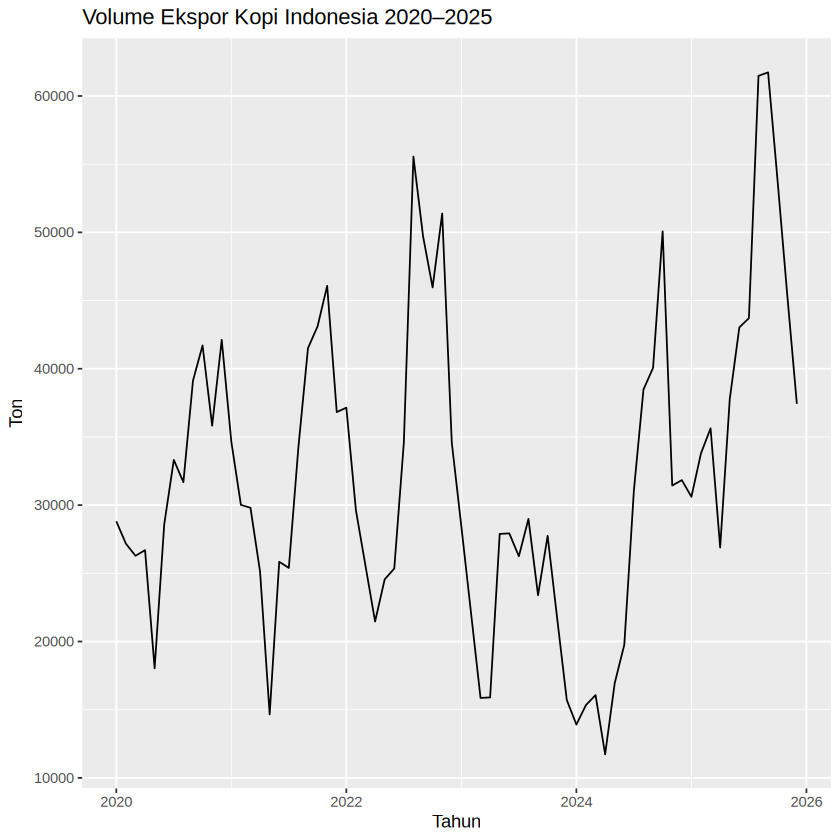

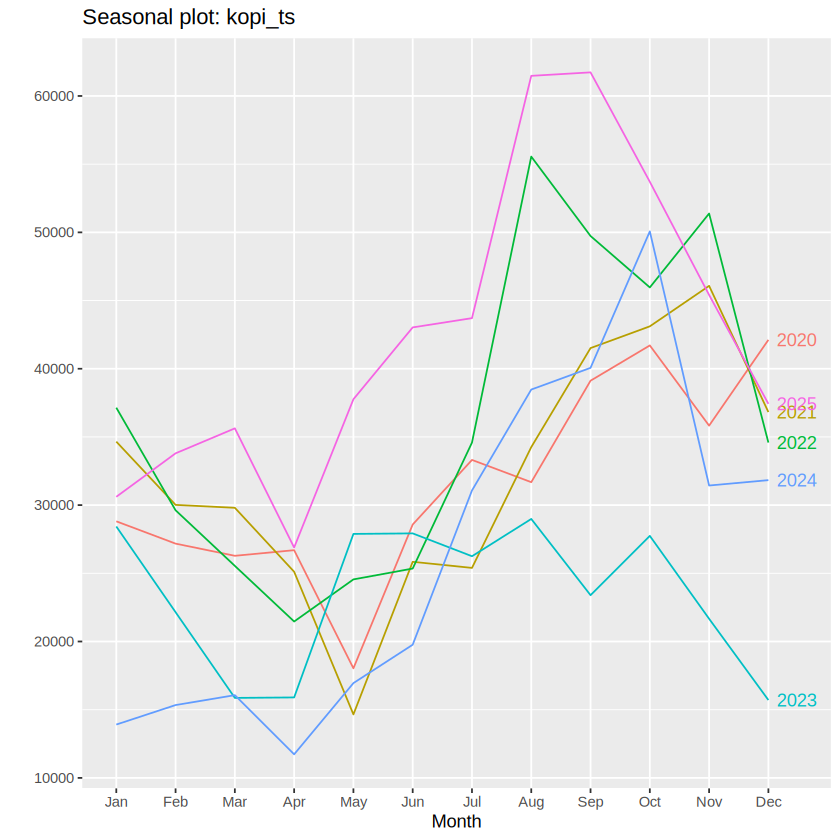

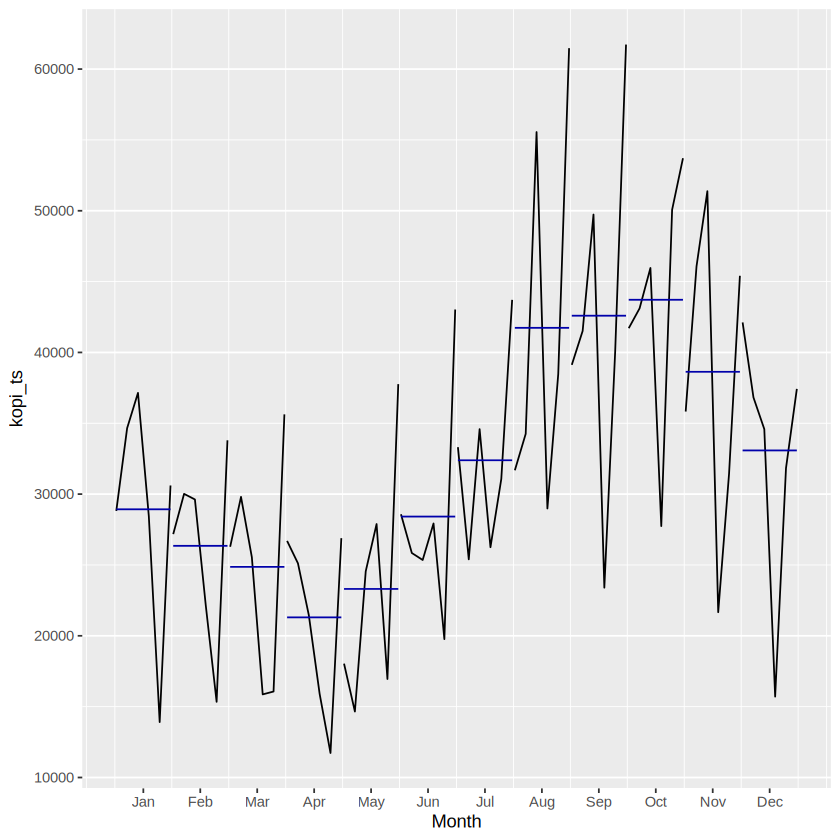

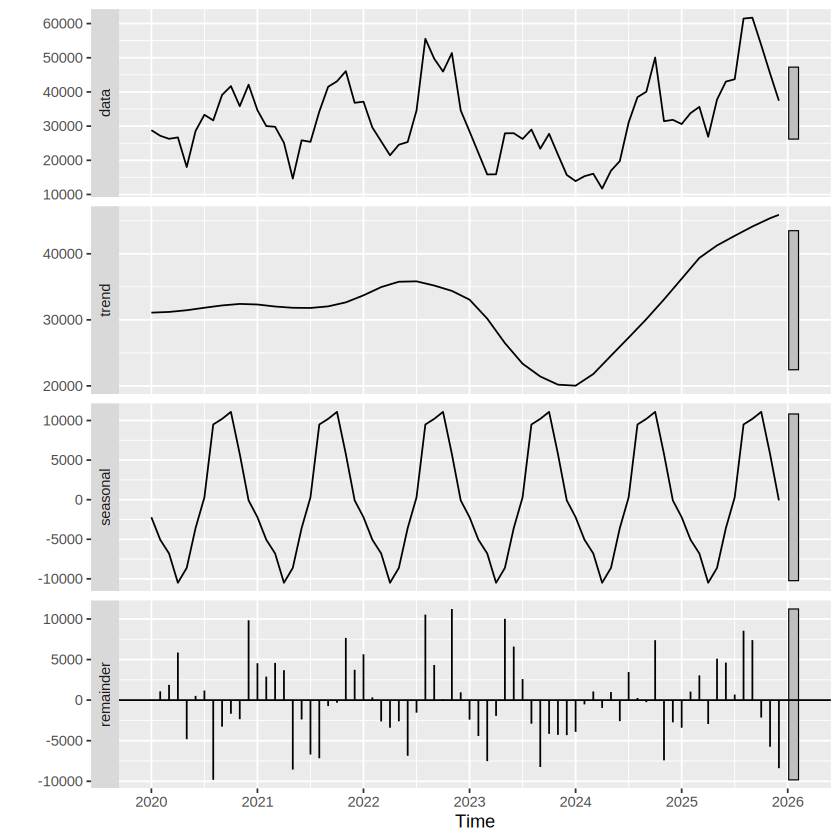

In [ ]:
# install.packages(c("forecast", "tseries"))
library(forecast)
library(tseries)

kopi_ts <- ts(data_kopi$volume_ton_clean, start = c(2020, 1), frequency = 12)

autoplot(kopi_ts) +
  labs(title = "Volume Ekspor Kopi Indonesia 2020–2025", x = "Tahun", y = "Ton")

ggseasonplot(kopi_ts, year.labels = TRUE)
ggsubseriesplot(kopi_ts)
autoplot(stl(kopi_ts, s.window = "periodic"))

# simpan data bersih agar tidak hilang kalau sesi Colab terputus
write.csv(
  data_kopi %>% select(tanggal, netWgt, volume_ton, volume_ton_clean),
  "data_kopi_clean.csv", row.names = FALSE
)

[1] 1

Warning message in adf.test(train):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  train
Dickey-Fuller = -5.6494, Lag order = 3, p-value = 0.01
alternative hypothesis: stationary


[1] 0


	Augmented Dickey-Fuller Test

data:  train_s
Dickey-Fuller = -2.1081, Lag order = 3, p-value = 0.5309
alternative hypothesis: stationary


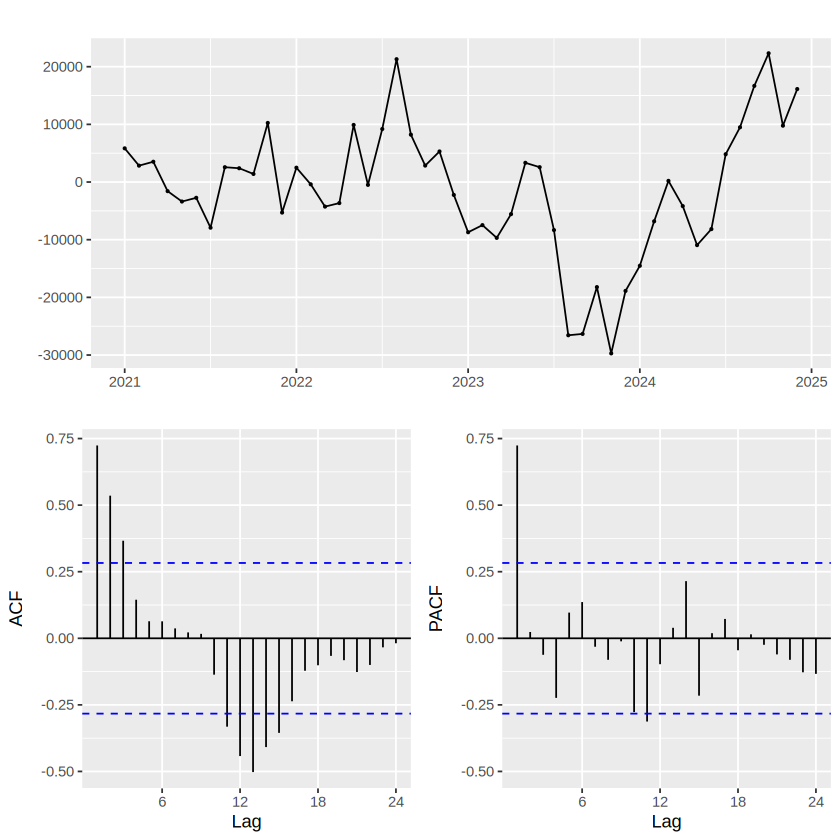

In [ ]:
library(forecast)
library(tseries)

# Pembagian data
train <- window(kopi_ts, end = c(2024, 12))
test  <- window(kopi_ts, start = c(2025, 1))

# Orde differencing yang disarankan
nsdiffs(train)                    # D (musiman)
adf.test(train)                   # ADF pada data asli

train_s <- diff(train, lag = 12)  # setelah differencing musiman
ndiffs(train_s)                   # d (biasa)
adf.test(train_s)

# Plot ACF/PACF setelah differencing musiman
ggtsdisplay(train_s, lag.max = 24)

In [ ]:
#bandingkan beberapa kandidat model
library(forecast)

spec <- list(
  A = list(order = c(1,0,0), seasonal = c(0,1,0)),
  B = list(order = c(1,0,0), seasonal = c(0,1,1)),
  C = list(order = c(0,1,0), seasonal = c(0,1,0)),
  D = list(order = c(0,1,1), seasonal = c(0,1,1)),
  E = list(order = c(1,1,0), seasonal = c(0,1,1))
)

tabel <- do.call(rbind, lapply(names(spec), function(n) {
  m  <- Arima(train, order = spec[[n]]$order,
              seasonal = list(order = spec[[n]]$seasonal, period = 12))
  lb <- Box.test(residuals(m), lag = 12, type = "Ljung-Box",
                 fitdf = length(m$coef))
  data.frame(model = n, AICc = round(m$aicc, 1), BIC = round(m$bic, 1),
             LjungBox_p = round(lb$p.value, 3))
}))
tabel

# pembanding otomatis
auto.arima(train, stepwise = FALSE, approximation = FALSE)

model,AICc,BIC,LjungBox_p
<chr>,<dbl>,<dbl>,<dbl>
A,997.1,1000.6,0.228
B,995.3,1000.3,0.057
C,979.5,981.3,0.117
D,978.3,983.3,0.026
E,979.0,984.0,0.012


Series: train 
ARIMA(0,0,3)(0,1,1)[12] 

Coefficients:
         ma1    ma2     ma3     sma1
      0.5895  0.475  0.4719  -0.6683
s.e.  0.1427  0.160  0.1101   0.2886

sigma^2 = 42853172:  log likelihood = -491.78
AIC=993.55   AICc=994.98   BIC=1002.91


z test of coefficients:

     Estimate Std. Error z value  Pr(>|z|)    
ar1   0.67791    0.10520  6.4443 1.162e-10 ***
sma1 -0.54679    0.26410 -2.0703   0.03842 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



z test of coefficients:

     Estimate Std. Error z value  Pr(>|z|)    
ma1   0.58951    0.14273  4.1304 3.622e-05 ***
ma2   0.47503    0.16003  2.9684  0.002993 ** 
ma3   0.47187    0.11013  4.2845 1.831e-05 ***
sma1 -0.66831    0.28859 -2.3158  0.020570 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



	Ljung-Box test

data:  Residuals from ARIMA(1,0,0)(0,1,1)[12]
Q* = 17.878, df = 10, p-value = 0.05705

Model df: 2.   Total lags used: 12



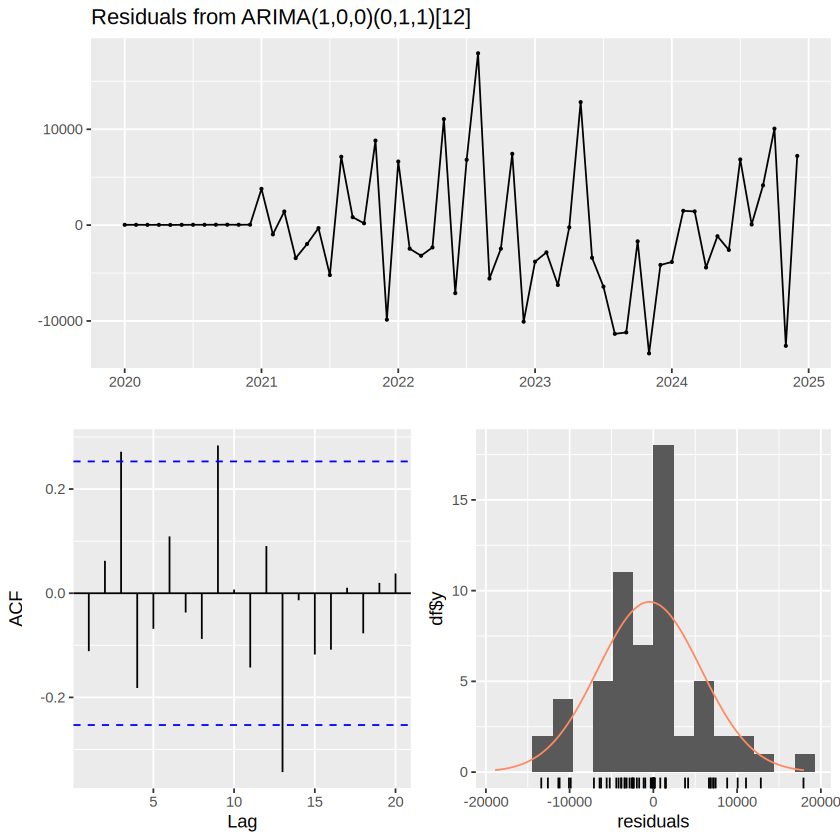


	Ljung-Box test

data:  Residuals from ARIMA(0,1,0)(0,1,0)[12]
Q* = 17.958, df = 12, p-value = 0.117

Model df: 0.   Total lags used: 12



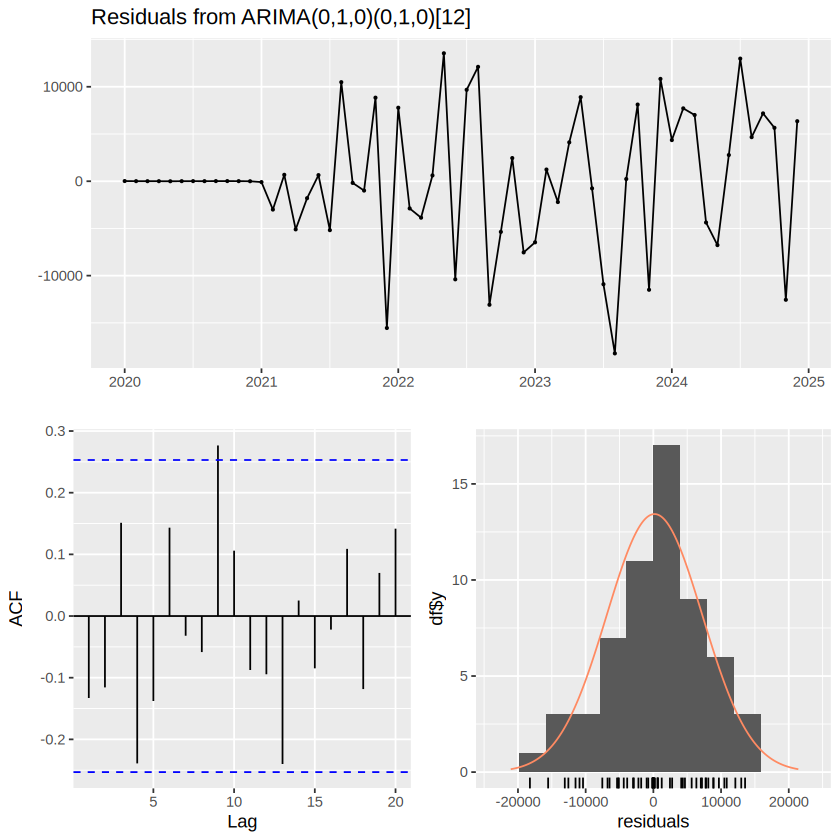


	Ljung-Box test

data:  Residuals from ARIMA(0,0,3)(0,1,1)[12]
Q* = 9.8203, df = 8, p-value = 0.2779

Model df: 4.   Total lags used: 12



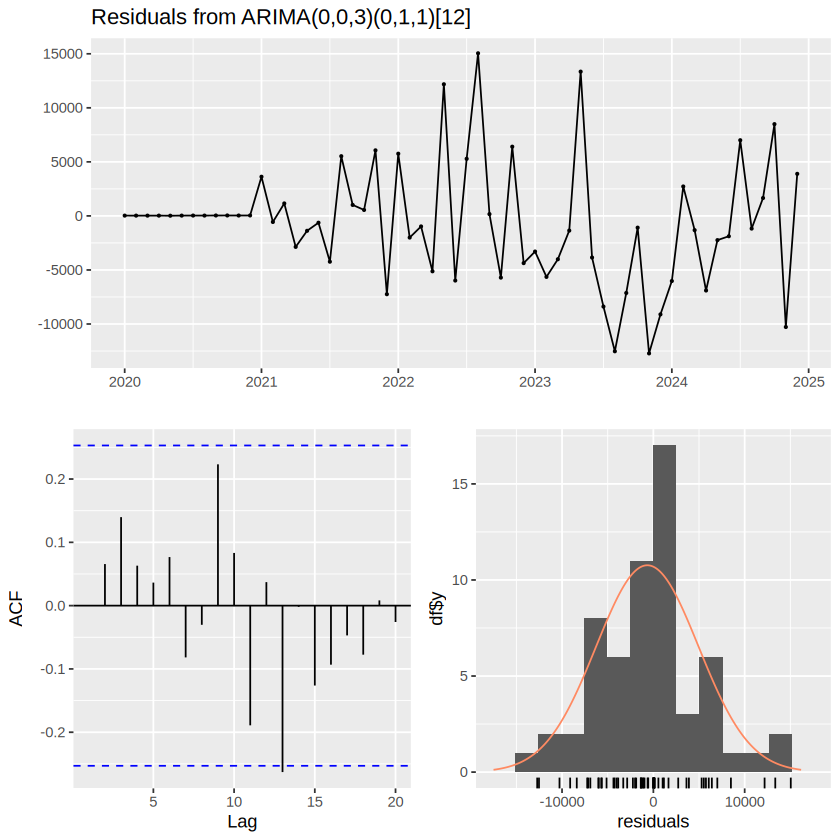

In [ ]:
#periksa 3 model
library(lmtest)   # install.packages("lmtest") bila belum ada

mB    <- Arima(train, order = c(1,0,0), seasonal = list(order = c(0,1,1), period = 12))
mC    <- Arima(train, order = c(0,1,0), seasonal = list(order = c(0,1,0), period = 12))
mAuto <- Arima(train, order = c(0,0,3), seasonal = list(order = c(0,1,1), period = 12))

coeftest(mB)       # signifikansi parameter B
coeftest(mAuto)

checkresiduals(mB,    lag = 12)
checkresiduals(mC,    lag = 12)
checkresiduals(mAuto, lag = 12)

In [ ]:
confint(mB)
confint(mAuto)

,2.5 %,97.5 %
ar1,0.4717315,0.88409443
sma1,-1.0644218,-0.02915337


,2.5 %,97.5 %
ma1,0.3097744,0.8692530
ma2,0.1613852,0.7886815
ma3,0.2560102,0.6877236
sma1,-1.2339257,-0.1026874


In [ ]:
#hitung ulang diagnostik tanpa residual nol u/ semua kandidat
spec <- list(
  A    = list(order = c(1,0,0), seasonal = c(0,1,0)),
  B    = list(order = c(1,0,0), seasonal = c(0,1,1)),
  C    = list(order = c(0,1,0), seasonal = c(0,1,0)),
  D    = list(order = c(0,1,1), seasonal = c(0,1,1)),
  E    = list(order = c(1,1,0), seasonal = c(0,1,1)),
  auto = list(order = c(0,0,3), seasonal = c(0,1,1))
)

tabel <- do.call(rbind, lapply(names(spec), function(n) {
  m    <- Arima(train, order = spec[[n]]$order,
                seasonal = list(order = spec[[n]]$seasonal, period = 12))
  skip <- spec[[n]]$order[2] + 12 * spec[[n]]$seasonal[2]  # jumlah residual nol di awal
  res  <- residuals(m)[-(1:skip)]
  lb   <- Box.test(res, lag = 12, type = "Ljung-Box", fitdf = length(m$coef))
  data.frame(model = n, AICc = round(m$aicc, 1), BIC = round(m$bic, 1),
             n_res = length(res), LB_p = round(lb$p.value, 3),
             Shapiro_p = round(shapiro.test(res)$p.value, 3))
}))
tabel

model,AICc,BIC,n_res,LB_p,Shapiro_p
<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
A,997.1,1000.6,48,0.378,0.686
B,995.3,1000.3,48,0.136,0.308
C,979.5,981.3,47,0.258,0.378
D,978.3,983.3,47,0.081,0.756
E,979.0,984.0,47,0.047,0.803
auto,995.0,1002.9,48,0.419,0.375


In [ ]:
#validasi berulang di data latih
f_B    <- function(y, h) forecast(Arima(y, order = c(1,0,0), seasonal = c(0,1,1)), h = h)
f_auto <- function(y, h) forecast(Arima(y, order = c(0,0,3), seasonal = c(0,1,1)), h = h)
f_C    <- function(y, h) forecast(Arima(y, order = c(0,1,0), seasonal = c(0,1,0)), h = h)
f_sn   <- function(y, h) snaive(y, h = h)

e_B    <- tsCV(train, f_B,    h = 12, initial = 36)
e_auto <- tsCV(train, f_auto, h = 12, initial = 36)
e_C    <- tsCV(train, f_C,    h = 12, initial = 36)
e_sn   <- tsCV(train, f_sn,   h = 12, initial = 36)

rmse_h <- function(e) sqrt(colMeans(e^2, na.rm = TRUE))
hasil  <- rbind(B = rmse_h(e_B), auto = rmse_h(e_auto),
                C = rmse_h(e_C), snaive = rmse_h(e_sn))
round(hasil[, c(1, 3, 6, 12)])

,h=1,h=3,h=6,h=12
B,9078,13627,15447,9209
auto,9764,13881,14760,8815
C,8189,14953,19414,26145
snaive,14662,15110,16238,11923


In [ ]:
#uji klp d=1
f_D <- function(y, h) forecast(Arima(y, order = c(0,1,1), seasonal = c(0,1,1)), h = h)
e_D <- tsCV(train, f_D, h = 12, initial = 36)
round(rmse_h(e_D)[c(1, 3, 6, 12)])

h=1   h=3   h=6  h=12 
 8774 13621 16772 21686

,RMSE,MAE,MAPE
B,15050.09,13859.87,32.07211
auto,15078.52,13872.17,32.13795
snaive,17330.94,16205.30,40.29500


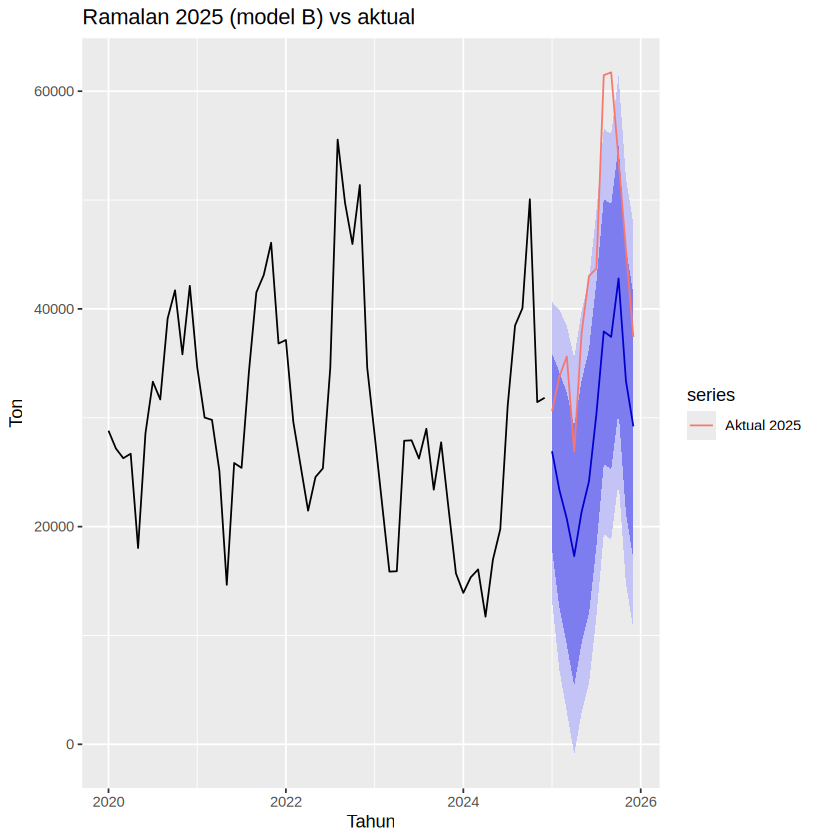

In [ ]:
#evaluasi data uji 2025, B dan auto dibandingkan dgn snaive
fc_B    <- forecast(mB,    h = 12)
fc_auto <- forecast(mAuto, h = 12)
fc_sn   <- snaive(train,   h = 12)

rbind(
  B      = accuracy(fc_B,    test)["Test set", c("RMSE", "MAE", "MAPE")],
  auto   = accuracy(fc_auto, test)["Test set", c("RMSE", "MAE", "MAPE")],
  snaive = accuracy(fc_sn,   test)["Test set", c("RMSE", "MAE", "MAPE")]
)

autoplot(fc_B) +
  autolayer(test, series = "Aktual 2025") +
  labs(title = "Ramalan 2025 (model B) vs aktual", x = "Tahun", y = "Ton")

Series: kopi_ts 
ARIMA(1,0,0)(0,1,1)[12] 

Coefficients:
         ar1     sma1
      0.7719  -0.6321
s.e.  0.0818   0.2089

sigma^2 = 46475638:  log likelihood = -617.21
AIC=1240.42   AICc=1240.85   BIC=1246.71

Training set error measures:
                   ME     RMSE      MAE       MPE     MAPE      MASE       ACF1
Training set 313.2011 6118.718 4443.877 -1.345051 14.44703 0.4415515 -0.1365452


z test of coefficients:

      Estimate Std. Error z value  Pr(>|z|)    
ar1   0.771901   0.081786  9.4381 < 2.2e-16 ***
sma1 -0.632075   0.208854 -3.0264  0.002475 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


,2.5 %,97.5 %
ar1,0.6116042,0.9321979
sma1,-1.0414223,-0.2227277



	Box-Ljung test

data:  res_f
X-squared = 14.247, df = 10, p-value = 0.162



	Shapiro-Wilk normality test

data:  res_f
W = 0.98722, p-value = 0.7841



	Ljung-Box test

data:  Residuals from ARIMA(1,0,0)(0,1,1)[12]
Q* = 16.728, df = 10, p-value = 0.08061

Model df: 2.   Total lags used: 12



         Point Forecast    Lo 80    Hi 80     Lo 95    Hi 95
Jan 2026       33049.32 24292.62 41806.02 19657.098 46441.54
Feb 2026       31051.43 19997.08 42105.79 14145.255 47957.61
Mar 2026       29413.22 17193.57 41632.88 10724.873 48101.57
Apr 2026       23598.89 10735.03 36462.74  3925.311 43272.46
May 2026       29118.63 15885.88 42351.38  8880.890 49356.37
Jun 2026       32819.41 19371.75 46267.07 12252.993 53385.83
Jul 2026       36328.41 22754.45 49902.37 15568.823 57088.00
Aug 2026       47526.13 33877.67 61174.58 26652.616 68399.64
Sep 2026       47302.68 33610.38 60994.97 26362.123 68243.23
Oct 2026       47068.09 33350.34 60785.84 26088.598 68047.59
Nov 2026       38900.36 25168.45 52632.27 17899.216 59901.50
Dec 2026       32964.51 19225.84 46703.18 11953.023 53976.00

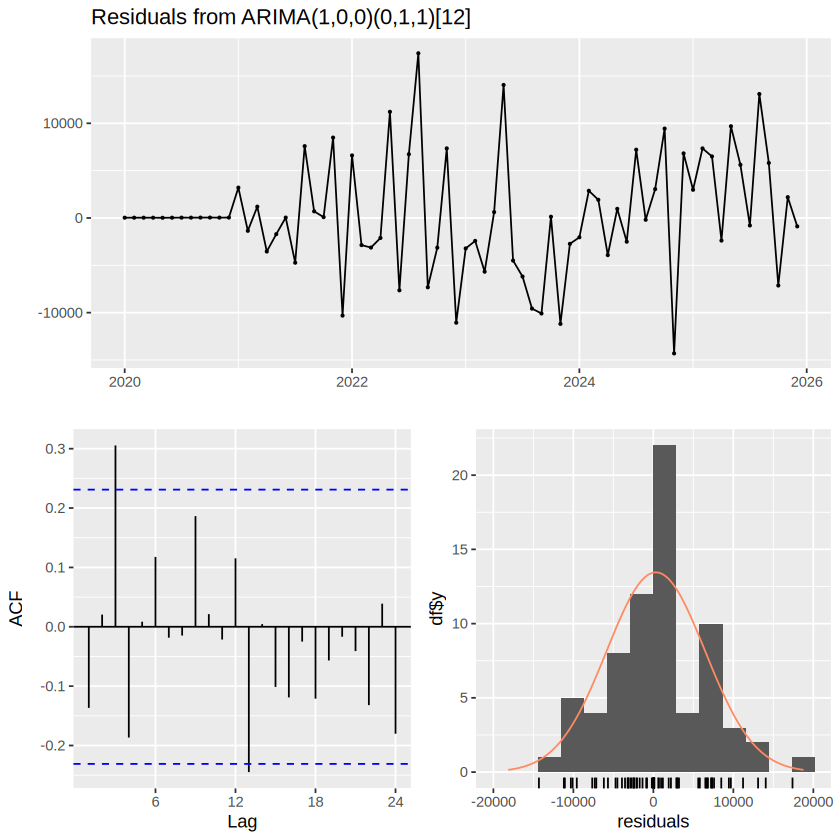

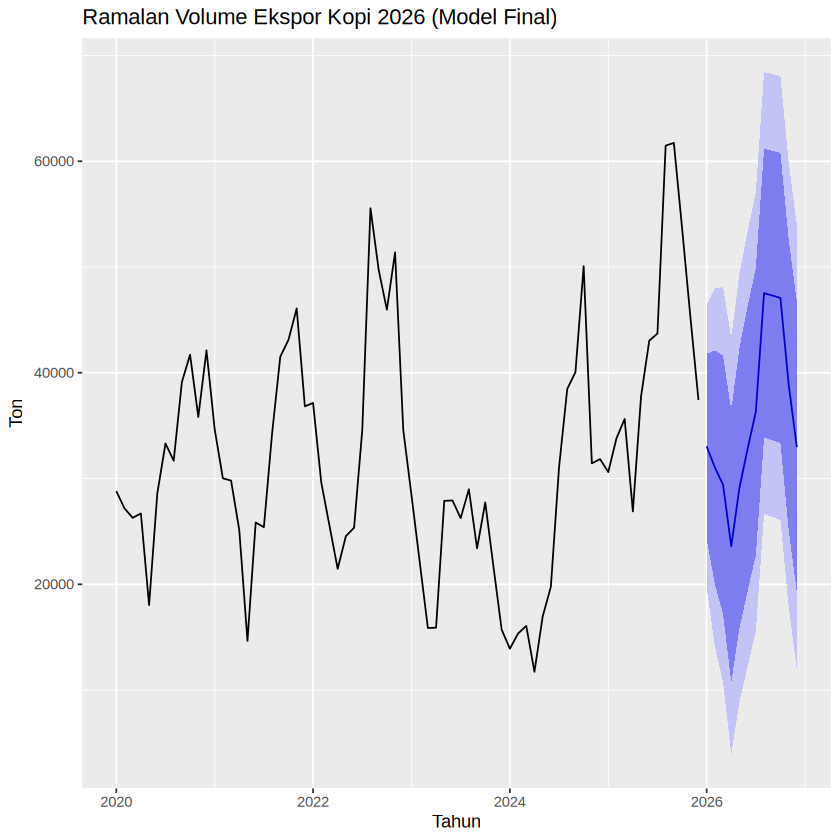

In [ ]:
library(lmtest)

# Model final: seluruh data 2020-2025
mFinal <- Arima(kopi_ts, order = c(1,0,0),
                seasonal = list(order = c(0,1,1), period = 12))
summary(mFinal)
coeftest(mFinal)
confint(mFinal)

# Diagnostik residual (tanpa 12 residual nol di awal)
res_f <- residuals(mFinal)[-(1:12)]
Box.test(res_f, lag = 12, type = "Ljung-Box", fitdf = length(mFinal$coef))
shapiro.test(res_f)
checkresiduals(mFinal, lag = 12)   # p-value di output ini jangan dipakai; pakai Box.test di atas

# Ramalan 2026
fc_2026 <- forecast(mFinal, h = 12, level = c(80, 95))
fc_2026
autoplot(fc_2026) +
  labs(title = "Ramalan Volume Ekspor Kopi 2026 (Model Final)",
       x = "Tahun", y = "Ton")

# Simpan hasil agar tidak hilang bila sesi Colab terputus
hasil_2026 <- data.frame(
  bulan   = seq(as.Date("2026-01-01"), by = "month", length.out = 12),
  ramalan = as.numeric(fc_2026$mean),
  bawah95 = as.numeric(fc_2026$lower[, "95%"]),
  atas95  = as.numeric(fc_2026$upper[, "95%"])
)
write.csv(hasil_2026, "ramalan_2026.csv", row.names = FALSE)

In [ ]:
#uji sesivitas imputasi data yg sdh dilakukan
alt <- kopi_ts
alt[27] <- 26419    # Maret 2022, estimasi dari harga satuan
alt[38] <- 20536    # Februari 2023

mAlt <- Arima(alt, order = c(1,0,0), seasonal = list(order = c(0,1,1), period = 12))

round(rbind(utama = coef(mFinal), alternatif = coef(mAlt)), 3)
round(cbind(utama = fc_2026$mean, alternatif = forecast(mAlt, h = 12)$mean))

,ar1,sma1
utama,0.772,-0.632
alternatif,0.773,-0.635


,utama,alternatif
Jan 2026,33049,33051
Feb 2026,31051,30789
Mar 2026,29413,29482
Apr 2026,23599,23597
May 2026,29119,29077
Jun 2026,32819,32785
Jul 2026,36328,36297
Aug 2026,47526,47470
Sep 2026,47303,47252
Oct 2026,47068,47035


In [ ]:
#simpan grafik bwt laporan
p <- autoplot(fc_2026) +
  labs(title = "Ramalan Volume Ekspor Kopi 2026 (Model Final)", x = "Tahun", y = "Ton")
ggsave("ramalan_2026.png", p, width = 8, height = 5, dpi = 300)